# Titration curves and results

Every figure below is regenerated from the forward model or from the committed result files. Nothing is hard coded.

The chemistry sections need only the package. The results sections read `results/*.json` and skip themselves cleanly if those files are absent.

In [1]:
from pathlib import Path
import sys, json

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cleaned_reef_water.alkalinity import constants_at, speciate
from cleaned_reef_water.titration import simulate_titration

RESULTS = ROOT / "results"

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9.5,
    "axes.titlesize": 10.5,
    "legend.frameon": False,
})

MASS_LABEL = "titrant delivered, g"
PH_LABEL = "pH, total scale"

# Reference state used throughout unless a sweep varies one of these.
REF = dict(alkalinity=2300e-6, dic=2000e-6, salinity=35.0, t_c=25.0)

def curve(n_points=400, **kw):
    """Simulate at the reference state with any keyword overridden."""
    state = {**REF, **kw}
    return simulate_titration(n_points=n_points, **state)

print("package loaded from", ROOT / "src")

package loaded from /sessions/awesome-beautiful-brahmagupta/mnt/Reef_Water_Cleanup/cleaned_reef_water/src


## 1. A single titration curve

The reference state: $A_T = 2300$, $C_T = 2000\ \mu\mathrm{mol\,kg^{-1}}$, $S = 35$, $t = 25^\circ\mathrm{C}$, on a $0.015\ \mathrm{kg}$ sample titrated with $0.1\ \mathrm{mol\,kg^{-1}}$ HCl.

The equivalence point is where the added acid has consumed exactly the alkalinity,

$$m_{eq} = \frac{m_0 A_T}{C_a}$$

which for this state is $3.45\times10^{-4}\ \mathrm{kg}$.

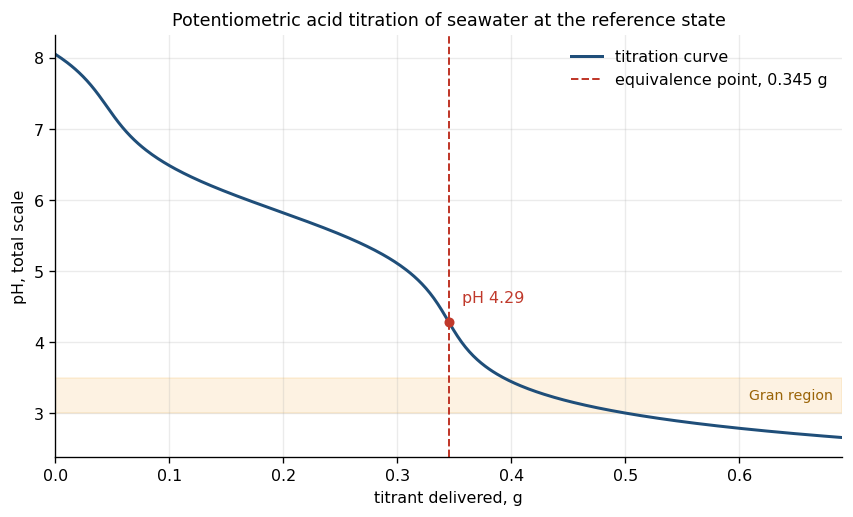

initial pH        8.0459
pH at equivalence 4.2886
final pH          2.6616
monotone decreasing: True


In [2]:
c = curve()
mass_g = c.titrant_mass * 1e3
eq_g = c.equivalence_mass * 1e3

fig, ax = plt.subplots()
ax.plot(mass_g, c.ph_total, color="#1f4e79", lw=1.8, label="titration curve")
ax.axvline(eq_g, color="#c0392b", ls="--", lw=1.2,
           label=f"equivalence point, {eq_g:.3f} g")

ph_eq = float(np.interp(c.equivalence_mass, c.titrant_mass, c.ph_total))
ax.plot([eq_g], [ph_eq], "o", color="#c0392b", ms=5, zorder=5)
ax.annotate(f"pH {ph_eq:.2f}", xy=(eq_g, ph_eq), xytext=(8, 12),
            textcoords="offset points", color="#c0392b")

ax.axhspan(3.0, 3.5, color="#f39c12", alpha=0.12)
ax.text(mass_g[-1], 3.25, "Gran region  ", ha="right", va="center",
        color="#9a6407", fontsize=8.5)

ax.set_xlabel(MASS_LABEL)
ax.set_ylabel(PH_LABEL)
ax.set_title("Potentiometric acid titration of seawater at the reference state")
ax.set_xlim(0, mass_g[-1])
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

print(f"initial pH        {c.ph_total[0]:.4f}")
print(f"pH at equivalence {ph_eq:.4f}")
print(f"final pH          {c.ph_total[-1]:.4f}")
print(f"monotone decreasing: {bool(np.all(np.diff(c.ph_total) < 0))}")

### Where the curve is informative

The rate of pH change per unit titrant, $-\mathrm{d}\,\mathrm{pH}/\mathrm{d}m$, is the reciprocal of buffer capacity: it is small where the solution resists the added acid and large where nothing is left to buffer.

Two peaks appear, and only the second is the alkalinity endpoint. The first, near $0.045\ \mathrm{g}$, is the buffer minimum between the two carbonic dissociation constants. The trough between them sits at $\mathrm{p}K_1 = 5.85$, where bicarbonate buffers most strongly. The taller peak at the equivalence point is what locates $m_{eq}$, and therefore what determines the recovered alkalinity.

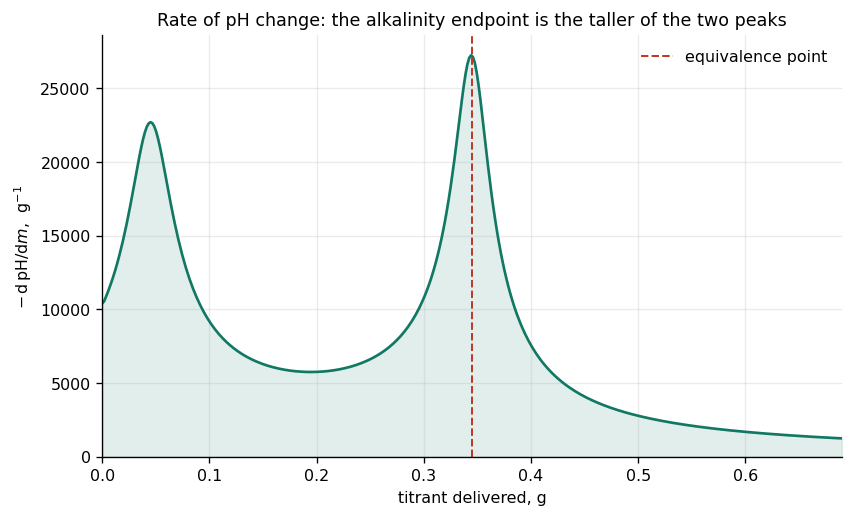

steepest descent at 0.344 g, against an equivalence mass of 0.345 g


In [3]:
d_ph = -np.gradient(c.ph_total, c.titrant_mass)

fig, ax = plt.subplots()
ax.plot(mass_g, d_ph, color="#117864", lw=1.6)
ax.axvline(eq_g, color="#c0392b", ls="--", lw=1.2, label="equivalence point")
ax.fill_between(mass_g, 0, d_ph, color="#117864", alpha=0.12)

ax.set_xlabel(MASS_LABEL)
ax.set_ylabel(r"$-\,\mathrm{d\,pH}/\mathrm{d}m$,  $\mathrm{g}^{-1}$")
ax.set_title("Rate of pH change: the alkalinity endpoint is the taller of the two peaks")
ax.set_xlim(0, mass_g[-1])
ax.set_ylim(bottom=0)
ax.legend()
fig.tight_layout()
plt.show()

peak = mass_g[int(np.argmax(d_ph))]
print(f"steepest descent at {peak:.3f} g, against an equivalence mass of {eq_g:.3f} g")

### Speciation through the titration

The same curve, resolved into the species that carry the alkalinity. Each total is diluted by the added titrant, so concentrations are corrected by $m_0/(m_0+m)$ before speciating.

Bicarbonate rises as carbonate is protonated, then falls as it is itself protonated to $\mathrm{CO_2}$. That handover is the shape the inverse problem has to read.

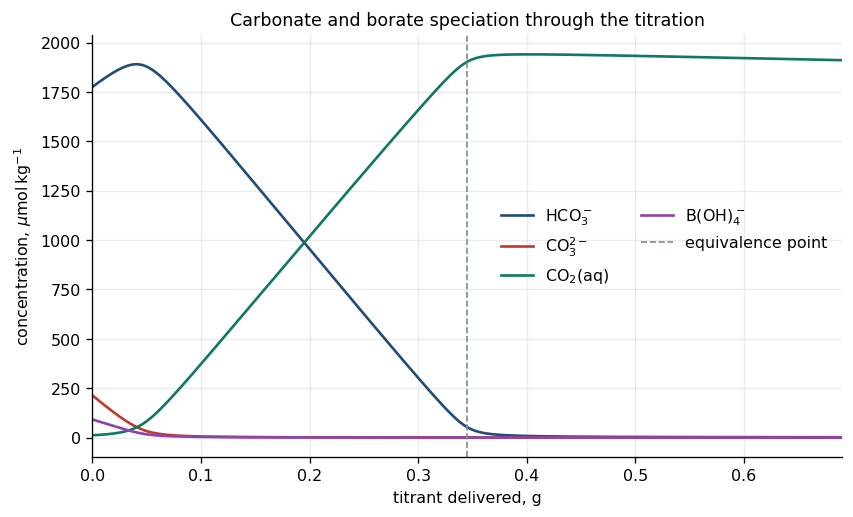

In [4]:
k = constants_at(REF["salinity"], REF["t_c"])
dilution = c.sample_mass / (c.sample_mass + c.titrant_mass)
sp = speciate(c.ph_total, k, dic=REF["dic"] * dilution)

fig, ax = plt.subplots()
for name, values, colour in [
    (r"$\mathrm{HCO_3^-}$", sp.hco3, "#1f4e79"),
    (r"$\mathrm{CO_3^{2-}}$", sp.co3, "#c0392b"),
    (r"$\mathrm{CO_2(aq)}$", sp.co2, "#117864"),
    (r"$\mathrm{B(OH)_4^-}$", sp.boh4, "#8e44ad"),
]:
    ax.plot(mass_g, np.asarray(values) * 1e6, lw=1.6, color=colour, label=name)

ax.axvline(eq_g, color="#7f8c8d", ls="--", lw=1.0, label="equivalence point")
ax.set_xlabel(MASS_LABEL)
ax.set_ylabel(r"concentration, $\mu\mathrm{mol\,kg^{-1}}$")
ax.set_title("Carbonate and borate speciation through the titration")
ax.set_xlim(0, mass_g[-1])
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

## 2. How the curve responds to its inputs

One input varied at a time, everything else held at the reference state. Each panel answers a different question about what the curve can and cannot reveal.

In [5]:
def sweep_axis(ax, key, values, label_fmt, cmap="viridis", mark_eq=True):
    """Overlay curves for one varied input, coloured light to dark."""
    colours = plt.get_cmap(cmap)(np.linspace(0.15, 0.9, len(values)))
    for value, colour in zip(values, colours):
        cv = curve(**{key: value})
        ax.plot(cv.titrant_mass * 1e3, cv.ph_total, color=colour, lw=1.5,
                label=label_fmt(value))
        if mark_eq:
            eq = cv.equivalence_mass
            ax.plot([eq * 1e3], [float(np.interp(eq, cv.titrant_mass, cv.ph_total))],
                    "o", color=colour, ms=3.5, zorder=5)
    ax.set_xlabel(MASS_LABEL)
    ax.set_ylabel(PH_LABEL)
    ax.legend(fontsize=8)

### Alkalinity

Alkalinity sets how much acid is needed to reach the equivalence point, so it translates the curve along the mass axis. The marked equivalence points move in proportion, which is the relationship a titration exists to exploit.

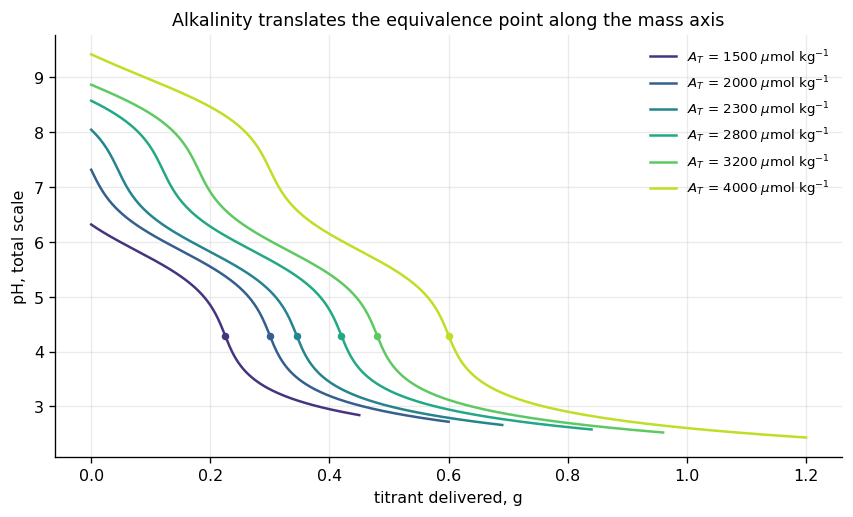

A_T =   1500 umol/kg  ->  equivalence mass 0.2250 g
A_T =   2300 umol/kg  ->  equivalence mass 0.3450 g
A_T =   4000 umol/kg  ->  equivalence mass 0.6000 g


In [6]:
fig, ax = plt.subplots()
sweep_axis(
    ax, "alkalinity",
    [1500e-6, 2000e-6, 2300e-6, 2800e-6, 3200e-6, 4000e-6],
    label_fmt=lambda v: rf"$A_T$ = {v*1e6:.0f} $\mu$mol kg$^{{-1}}$",
    cmap="viridis",
)
ax.set_title("Alkalinity translates the equivalence point along the mass axis")
fig.tight_layout()
plt.show()

for a in (1500e-6, 2300e-6, 4000e-6):
    cv = curve(alkalinity=a)
    print(f"A_T = {a*1e6:6.0f} umol/kg  ->  equivalence mass {cv.equivalence_mass*1e3:.4f} g")

### Carbon fraction

At fixed alkalinity, raising $C_T/A_T$ lowers the initial pH sharply, from $8.29$ at a ratio of $0.80$ to $7.66$ at $0.95$, because more of the alkalinity is carried by bicarbonate rather than carbonate.

The equivalence step itself barely changes: its peak steepness falls by only $8\%$ across that range, which is why the curves are almost indistinguishable near the endpoint. Carbon-rich water is harder to invert for a different reason, and it is a matter of what is left to measure rather than of curve shape. At a ratio of $0.80$ the water holds $317\ \mu\mathrm{mol\,kg^{-1}}$ of carbonate ion; at $0.95$ it holds $101$. The absolute uncertainty on carbonate hardly moves, so dividing a nearly constant error by a concentration three times smaller is what turns $1.4\%$ relative accuracy into $3.7\%$.

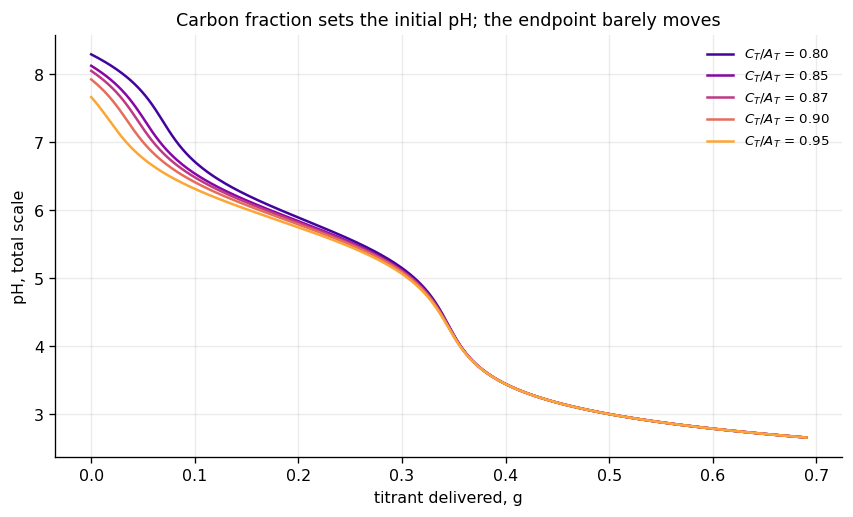

C_T/A_T = 0.80  ->  initial pH 8.287
C_T/A_T = 0.95  ->  initial pH 7.658


In [7]:
fig, ax = plt.subplots()
ratios = [0.80, 0.85, 0.87, 0.90, 0.95]
colours = plt.get_cmap("plasma")(np.linspace(0.1, 0.8, len(ratios)))
for r, colour in zip(ratios, colours):
    cv = curve(dic=REF["alkalinity"] * r)
    ax.plot(cv.titrant_mass * 1e3, cv.ph_total, color=colour, lw=1.5,
            label=rf"$C_T/A_T$ = {r:.2f}")
ax.set_xlabel(MASS_LABEL)
ax.set_ylabel(PH_LABEL)
ax.set_title("Carbon fraction sets the initial pH; the endpoint barely moves")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

for r in (0.80, 0.95):
    print(f"C_T/A_T = {r:.2f}  ->  initial pH {curve(dic=REF['alkalinity']*r).ph_total[0]:.3f}")

### Salinity and temperature

Both act on the equilibrium constants rather than on the totals, so both change the shape of the curve while leaving the equivalence mass fixed. An inverse that assumed constants at a single salinity and temperature would absorb this shape change as an error in the totals.

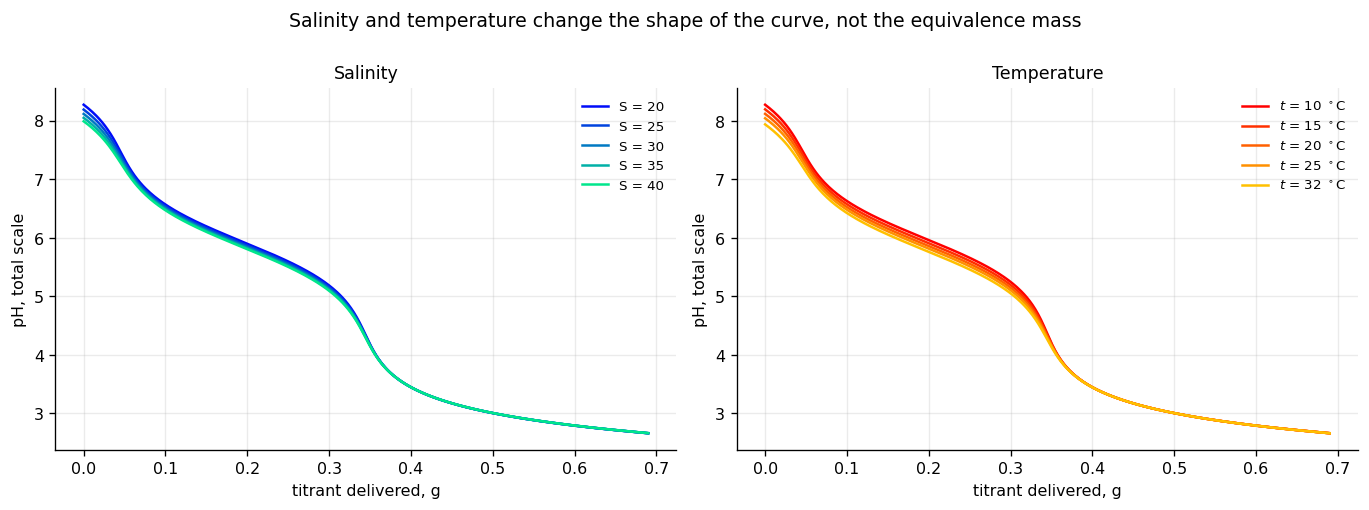

equivalence mass is unchanged across both sweeps:
  S = 20: 0.3450 g   S = 40: 0.3450 g


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

sal = [20.0, 25.0, 30.0, 35.0, 40.0]
colours = plt.get_cmap("winter")(np.linspace(0.05, 0.9, len(sal)))
for s, colour in zip(sal, colours):
    cv = curve(salinity=s)
    axes[0].plot(cv.titrant_mass * 1e3, cv.ph_total, color=colour, lw=1.5, label=f"S = {s:.0f}")
axes[0].set_title("Salinity")
axes[0].legend(fontsize=8)

temps = [10.0, 15.0, 20.0, 25.0, 32.0]
colours = plt.get_cmap("autumn")(np.linspace(0.0, 0.75, len(temps)))
for t, colour in zip(temps, colours):
    cv = curve(t_c=t)
    axes[1].plot(cv.titrant_mass * 1e3, cv.ph_total, color=colour, lw=1.5,
                 label=rf"$t$ = {t:.0f} $^\circ$C")
axes[1].set_title("Temperature")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel(MASS_LABEL)
    ax.set_ylabel(PH_LABEL)

fig.suptitle("Salinity and temperature change the shape of the curve, not the equivalence mass", y=1.0)
fig.tight_layout()
plt.show()

print("equivalence mass is unchanged across both sweeps:")
print(f"  S = 20: {curve(salinity=20.0).equivalence_mass*1e3:.4f} g"
      f"   S = 40: {curve(salinity=40.0).equivalence_mass*1e3:.4f} g")

### Organic alkalinity

Organic acid adds proton acceptance that the carbonate model has no term for. Its effect on the curve is small and, over most of the mass range, closely resembles a shift in the carbonate totals. That resemblance is exactly the identifiability problem: near a $\mathrm{p}K_a$ of $5.85$ the organic signature is almost entirely reproducible by the carbonate system.

The lower panel plots the difference against organic-free water, which is where the signature is visible at all.

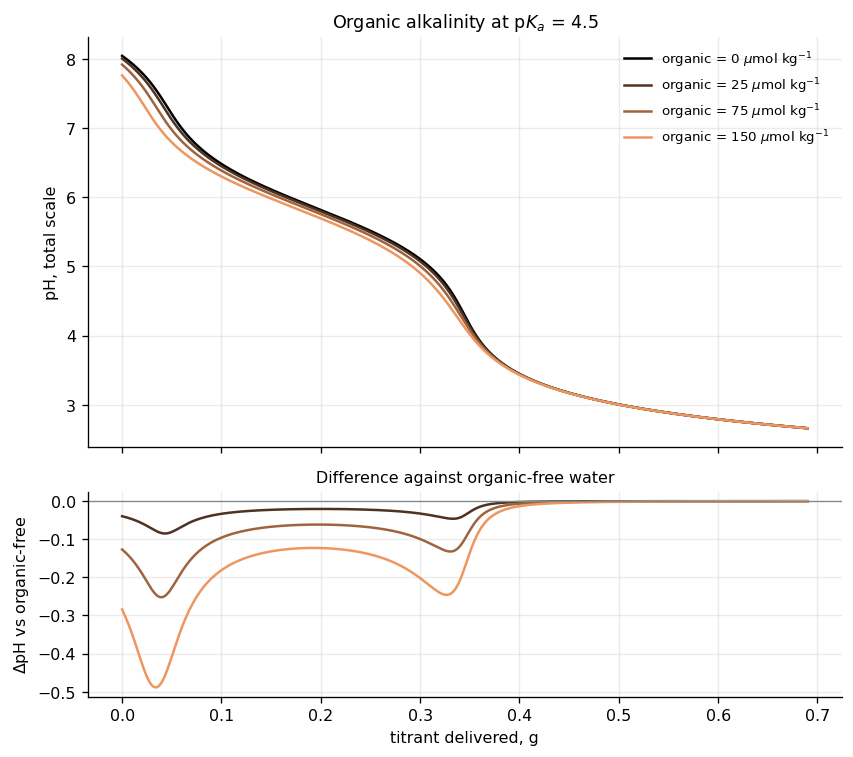

largest pH departure at 150 umol/kg organic: 0.4885
hobbyist electrode noise, for scale:            0.0349


In [9]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.2, 6.4), sharex=True,
                                  gridspec_kw={"height_ratios": [2, 1]})

base = curve(total_organic=0.0)
levels = [0.0, 25e-6, 75e-6, 150e-6]
colours = plt.get_cmap("copper")(np.linspace(0.0, 0.75, len(levels)))

for org, colour in zip(levels, colours):
    cv = curve(total_organic=org, pk_organic=4.5)
    top.plot(cv.titrant_mass * 1e3, cv.ph_total, color=colour, lw=1.5,
             label=rf"organic = {org*1e6:.0f} $\mu$mol kg$^{{-1}}$")
    if org > 0:
        bottom.plot(cv.titrant_mass * 1e3, cv.ph_total - base.ph_total,
                    color=colour, lw=1.5)

top.set_ylabel(PH_LABEL)
top.set_title(r"Organic alkalinity at $\mathrm{p}K_a$ = 4.5")
top.legend(fontsize=8)

bottom.axhline(0, color="#7f8c8d", lw=0.8)
bottom.set_xlabel(MASS_LABEL)
bottom.set_ylabel(r"$\Delta$pH vs organic-free")
bottom.set_title("Difference against organic-free water", fontsize=9.5)

fig.tight_layout()
plt.show()

worst = np.max(np.abs(curve(total_organic=150e-6).ph_total - base.ph_total))
print(f"largest pH departure at 150 umol/kg organic: {worst:.4f}")
print("hobbyist electrode noise, for scale:            0.0349")

### The organic $\mathrm{p}K_a$ is what makes it separable

The same organic total at different $\mathrm{p}K_a$ values. A weak acid dissociating well below the carbonic $\mathrm{p}K_1$ leaves a two-lobed signature with a sharp feature near the equivalence point; one dissociating at or above it leaves a single broad depression that fades early.

What this figure cannot show is which of these shapes the carbonate system could imitate by adjusting its own totals. That question needs the projection below, and its answer is the reason organic content is hard to recover: at $\mathrm{p}K_a = 5.85$ the signature is almost entirely reproducible, whatever its amplitude.

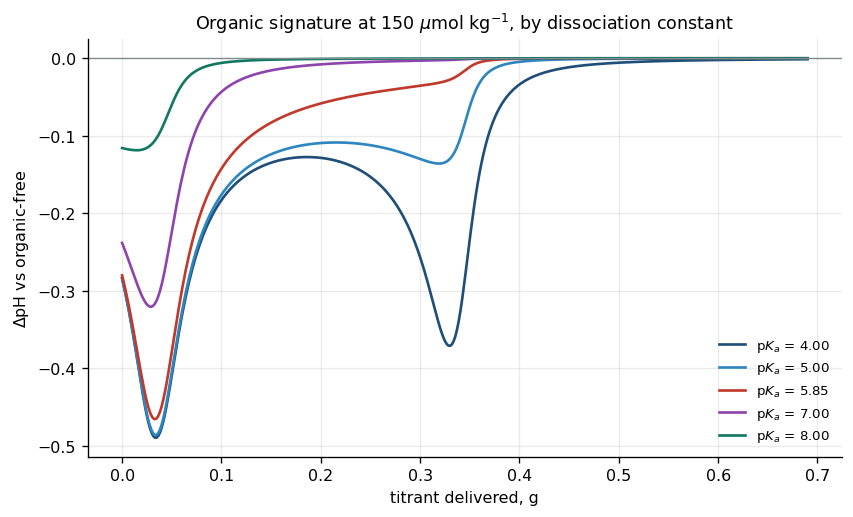

In [10]:
fig, ax = plt.subplots()
pks = [4.0, 5.0, 5.85, 7.0, 8.0]
colours = ["#1f4e79", "#2e86c1", "#c0392b", "#8e44ad", "#117864"]
for pk, colour in zip(pks, colours):
    cv = curve(total_organic=150e-6, pk_organic=pk)
    ax.plot(cv.titrant_mass * 1e3, cv.ph_total - base.ph_total, color=colour, lw=1.6,
            label=rf"$\mathrm{{p}}K_a$ = {pk:.2f}")

ax.axhline(0, color="#7f8c8d", lw=0.8)
ax.set_xlabel(MASS_LABEL)
ax.set_ylabel(r"$\Delta$pH vs organic-free")
ax.set_title(r"Organic signature at 150 $\mu$mol kg$^{-1}$, by dissociation constant")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 3. Results

The remaining figures read the committed result files. If a file is missing the cell prints a note and moves on, so the notebook still runs from a clean checkout.

In [11]:
def load(name):
    path = RESULTS / name
    if not path.exists():
        print(f"{name} not found; run the corresponding script to produce it.")
        return None
    return json.loads(path.read_text())

limits = load("limits.json")
organic = load("organic_comparison.json")
identifiability = load("organic_identifiability.json")

seeds = {}
for seed in (42, 43, 44):
    path = RESULTS / f"seed{seed}" / "autoencoder_hobbyist.json"
    if path.exists():
        seeds[seed] = json.loads(path.read_text())
print(f"training runs found: {sorted(seeds)}")

training runs found: [42, 43, 44]


### Where the accuracy comes from

Each bar removes one error mechanism and reports the resulting bound on alkalinity. The result is counterintuitive twice over: halving the electrode noise is worth almost nothing, and improving the pump, which does not change the pH scatter at all, is worth a factor of four.

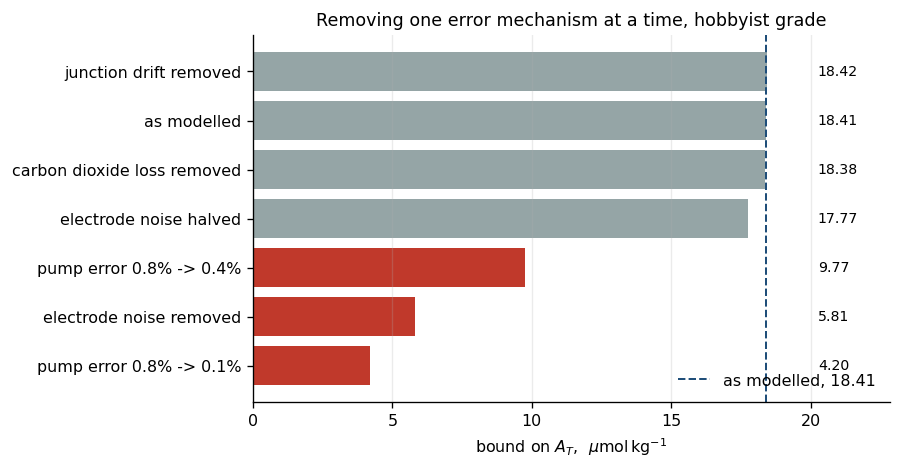

In [12]:
if limits:
    lev = limits["leverage_hobbyist"]
    rename = {"burette": "pump error", "CO2 degassing removed": "carbon dioxide loss removed"}
    labels = [rename.get(k, k.replace("burette", "pump error")) for k in lev]
    values = [lev[k] for k in lev]
    baseline = lev["as modelled"]

    order = np.argsort(values)
    labels = [labels[i] for i in order]
    values = [values[i] for i in order]
    colours = ["#c0392b" if v < baseline * 0.95 else "#95a5a6" for v in values]

    fig, ax = plt.subplots(figsize=(7.6, 4.0))
    ax.barh(labels, values, color=colours)
    ax.axvline(baseline, color="#1f4e79", ls="--", lw=1.2,
               label=f"as modelled, {baseline:.2f}")
    # Values in a right-aligned column: a per-bar offset collides with the
    # reference line whenever a bar happens to end just short of it.
    label_x = max(values) * 1.10
    for y, v in enumerate(values):
        ax.text(label_x, y, f"{v:.2f}", va="center", ha="left", fontsize=8.5)

    ax.set_xlabel(r"bound on $A_T$,  $\mu\mathrm{mol\,kg^{-1}}$")
    ax.set_title("Removing one error mechanism at a time, hobbyist grade")
    ax.set_xlim(0, max(values) * 1.24)
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()

### Accuracy across the composition range

The bound on each species over the sampled range of alkalinity and carbon fraction. The alkalinity bound scales almost exactly with alkalinity, so relative accuracy is roughly flat; carbon-rich water is consistently the harder case.

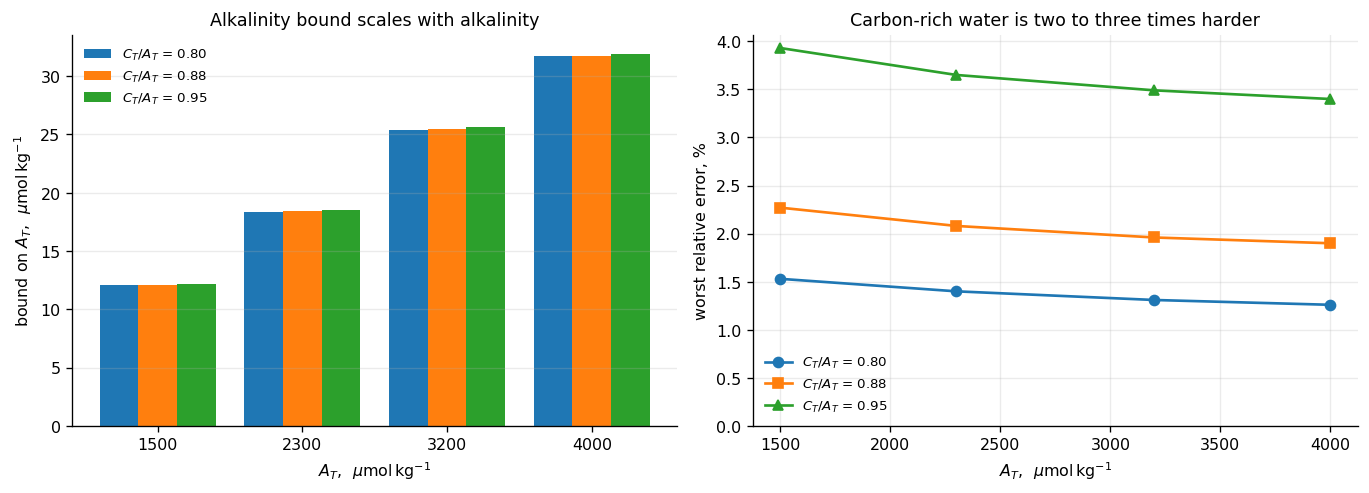

In [13]:
if limits:
    grid = limits["species_grid_hobbyist"]
    alks = sorted({g["alkalinity_umol_per_kg"] for g in grid})
    ratios = sorted({g["dic_over_alkalinity"] for g in grid})

    fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

    width = 0.8 / len(ratios)
    x = np.arange(len(alks))
    for i, r in enumerate(ratios):
        vals = [next(g["alkalinity_sd"] for g in grid
                     if g["alkalinity_umol_per_kg"] == a and g["dic_over_alkalinity"] == r)
                for a in alks]
        left.bar(x + (i - (len(ratios) - 1) / 2) * width, vals, width,
                 label=rf"$C_T/A_T$ = {r:.2f}")
    left.set_xticks(x, [f"{a:.0f}" for a in alks])
    left.set_xlabel(r"$A_T$,  $\mu\mathrm{mol\,kg^{-1}}$")
    left.set_ylabel(r"bound on $A_T$,  $\mu\mathrm{mol\,kg^{-1}}$")
    left.set_title("Alkalinity bound scales with alkalinity")
    left.legend(fontsize=8)
    left.grid(axis="x", visible=False)

    for r, marker in zip(ratios, ["o", "s", "^", "D"]):
        vals = [next(g["worst_relative_percent"] for g in grid
                     if g["alkalinity_umol_per_kg"] == a and g["dic_over_alkalinity"] == r)
                for a in alks]
        right.plot(alks, vals, marker=marker, lw=1.6, label=rf"$C_T/A_T$ = {r:.2f}")
    right.set_xlabel(r"$A_T$,  $\mu\mathrm{mol\,kg^{-1}}$")
    right.set_ylabel("worst relative error, %")
    right.set_title("Carbon-rich water is two to three times harder")
    right.set_ylim(bottom=0)
    right.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

### What the encoder recovers

The recovery ratio is the true spread of a parameter divided by the spread of the residual. Above one, the curve identifies the parameter. At one, the encoder is doing no better than predicting the population mean.

Calibration offset and slope are recovered well, which is what the whole inexpensive-instrument argument rests on. Pump scale is not recovered at all, and it is simultaneously the largest lever on achievable accuracy. A quantity that cannot be inferred has to be fixed in hardware.

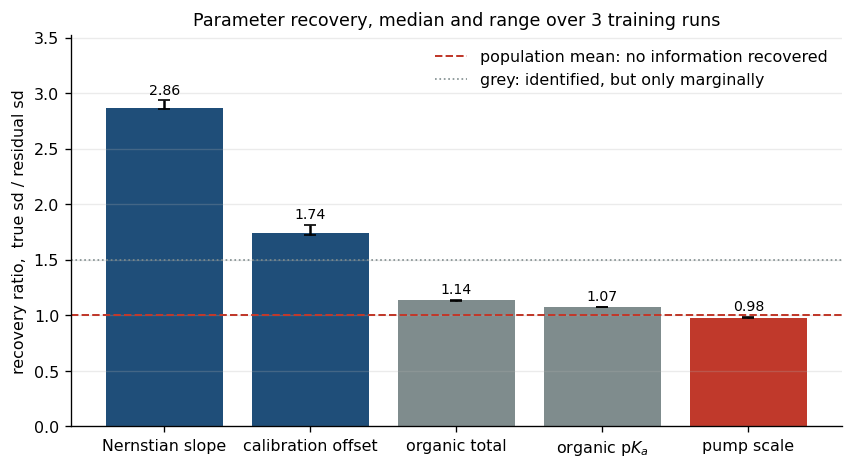

In [14]:
if seeds:
    order = ["slope", "offset", "total_organic", "pk_organic", "pump_scale"]
    pretty = {"slope": "Nernstian slope", "offset": "calibration offset",
              "total_organic": "organic total", "pk_organic": r"organic p$K_a$",
              "pump_scale": "pump scale"}

    med = [float(np.median([s["nuisance_recovery"][k]["recovery_ratio"] for s in seeds.values()]))
           for k in order]
    lo = [min(s["nuisance_recovery"][k]["recovery_ratio"] for s in seeds.values()) for k in order]
    hi = [max(s["nuisance_recovery"][k]["recovery_ratio"] for s in seeds.values()) for k in order]
    err = np.vstack([np.array(med) - np.array(lo), np.array(hi) - np.array(med)])

    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    # Three tiers, because "just above 1" is not the same claim as "well above 1".
    def tier(m):
        return "#1f4e79" if m > 1.5 else ("#7f8c8d" if m > 1.0 else "#c0392b")
    colours = [tier(m) for m in med]
    ax.bar([pretty[k] for k in order], med, yerr=err, capsize=3.5, color=colours)
    ax.axhline(1.0, color="#c0392b", ls="--", lw=1.2,
               label="population mean: no information recovered")
    ax.axhline(1.5, color="#7f8c8d", ls=":", lw=1.0,
               label="grey: identified, but only marginally")

    for i, m in enumerate(med):
        ax.text(i, hi[i] + 0.06, f"{m:.2f}", ha="center", fontsize=8.5)

    ax.set_ylabel("recovery ratio,  true sd / residual sd")
    ax.set_title(f"Parameter recovery, median and range over {len(seeds)} training runs")
    ax.set_ylim(0, max(hi) * 1.2)
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()

### Training variance

Three runs differing only in initialisation seed, on an identical held-out split. The spread measures training variance alone, and it is small enough that the headline figures are properties of the architecture rather than of one fortunate run.

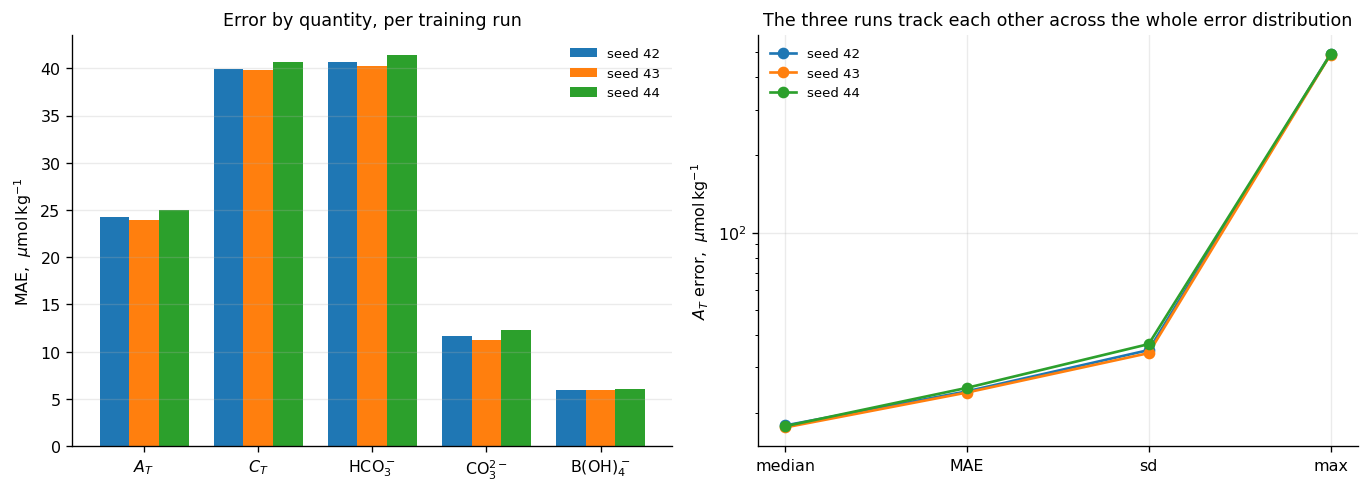

seed 42:  71 epochs   median  17.86   MAE  24.23   max  492.99
seed 43:  96 epochs   median  17.55   MAE  23.98   max  490.23
seed 44:  79 epochs   median  17.75   MAE  25.00   max  490.81


In [15]:
if seeds:
    quantities = ["alkalinity", "dic", "hco3", "co3", "boh4"]
    pretty = {"alkalinity": r"$A_T$", "dic": r"$C_T$", "hco3": r"$\mathrm{HCO_3^-}$",
              "co3": r"$\mathrm{CO_3^{2-}}$", "boh4": r"$\mathrm{B(OH)_4^-}$"}

    fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

    x = np.arange(len(quantities))
    for i, (seed, run) in enumerate(sorted(seeds.items())):
        vals = [run["metrics_umol_per_kg"][q]["mae"] for q in quantities]
        left.bar(x + (i - 1) * 0.26, vals, 0.26, label=f"seed {seed}")
    left.set_xticks(x, [pretty[q] for q in quantities])
    left.set_ylabel(r"MAE,  $\mu\mathrm{mol\,kg^{-1}}$")
    left.set_title("Error by quantity, per training run")
    left.legend(fontsize=8)
    left.grid(axis="x", visible=False)

    for seed, run in sorted(seeds.items()):
        m = run["metrics_umol_per_kg"]["alkalinity"]
        right.plot(["median", "MAE", "sd", "max"],
                   [m["median_abs"], m["mae"], m["sd"], m["max_abs"]],
                   marker="o", lw=1.6, label=f"seed {seed}")
    right.set_yscale("log")
    right.set_ylabel(r"$A_T$ error,  $\mu\mathrm{mol\,kg^{-1}}$")
    right.set_title("The three runs track each other across the whole error distribution")
    right.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

    for seed, run in sorted(seeds.items()):
        m = run["metrics_umol_per_kg"]["alkalinity"]
        print(f"seed {seed}: {run['epochs_run']:3d} epochs   "
              f"median {m['median_abs']:6.2f}   MAE {m['mae']:6.2f}   max {m['max_abs']:7.2f}")

### Organic water against the matched control

Both estimators on the same curves. Read the three groups in order, because the first constrains what the others are allowed to mean.

On organic-free water the learned model is worse: it predicts organic content that is not there, and the chemistry decoder subtracts it from the carbonate budget. On organic-carrying water the classical bias grows with organic content, because least squares has no term for it and attributes the proton acceptance to carbonate instead.

The bias plot is the result. The two lines cross, and where they cross is the decision about which estimator to use.

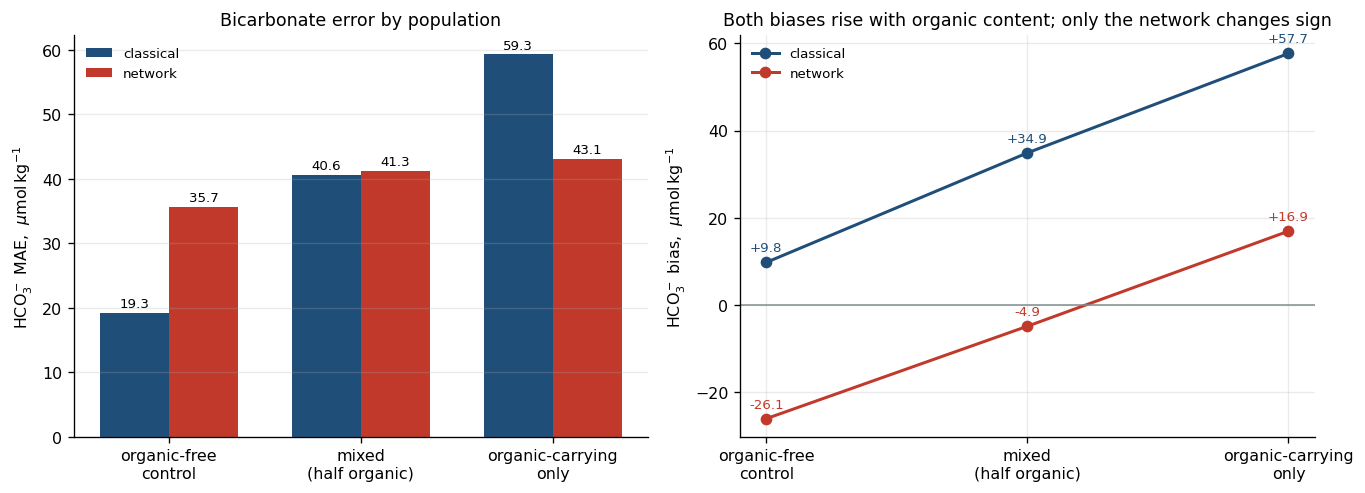

In [16]:
if organic:
    groups = ["control_organic_free", "mixed_organic_present", "mixed_organic_only"]
    pretty = ["organic-free\ncontrol", "mixed\n(half organic)", "organic-carrying\nonly"]

    fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

    x = np.arange(len(groups))
    for i, (est, colour) in enumerate([("classical", "#1f4e79"), ("network", "#c0392b")]):
        vals = [organic["groups"][g]["hco3"][est]["mae"] for g in groups]
        left.bar(x + (i - 0.5) * 0.36, vals, 0.36, color=colour, label=est)
        for xi, v in zip(x + (i - 0.5) * 0.36, vals):
            left.text(xi, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    left.set_xticks(x, pretty)
    left.set_ylabel(r"$\mathrm{HCO_3^-}$ MAE,  $\mu\mathrm{mol\,kg^{-1}}$")
    left.set_title("Bicarbonate error by population")
    left.legend(fontsize=8)
    left.grid(axis="x", visible=False)

    for est, colour in [("classical", "#1f4e79"), ("network", "#c0392b")]:
        vals = [organic["groups"][g]["hco3"][est]["bias"] for g in groups]
        right.plot(x, vals, marker="o", lw=1.8, color=colour, label=est)
        for xi, v in zip(x, vals):
            right.text(xi, v + 2.5, f"{v:+.1f}", ha="center", fontsize=8, color=colour)
    right.axhline(0, color="#7f8c8d", lw=0.9)
    right.set_xticks(x, pretty)
    right.set_ylabel(r"$\mathrm{HCO_3^-}$ bias,  $\mu\mathrm{mol\,kg^{-1}}$")
    right.set_title("Both biases rise with organic content; only the network changes sign")
    right.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

### Why organic content is hard to recover

The fraction of the organic signature that the carbonate system can already reproduce, swept over the organic $\mathrm{p}K_a$ and over the state space.

The minimum sits at the carbonic $\mathrm{p}K_1$: an organic acid dissociating where carbonate already dissociates is indistinguishable from a change in the totals. Across the twelve sampled states the independent fraction stays between one and three percent, which is why the encoder recovers organic content only barely above its population mean.

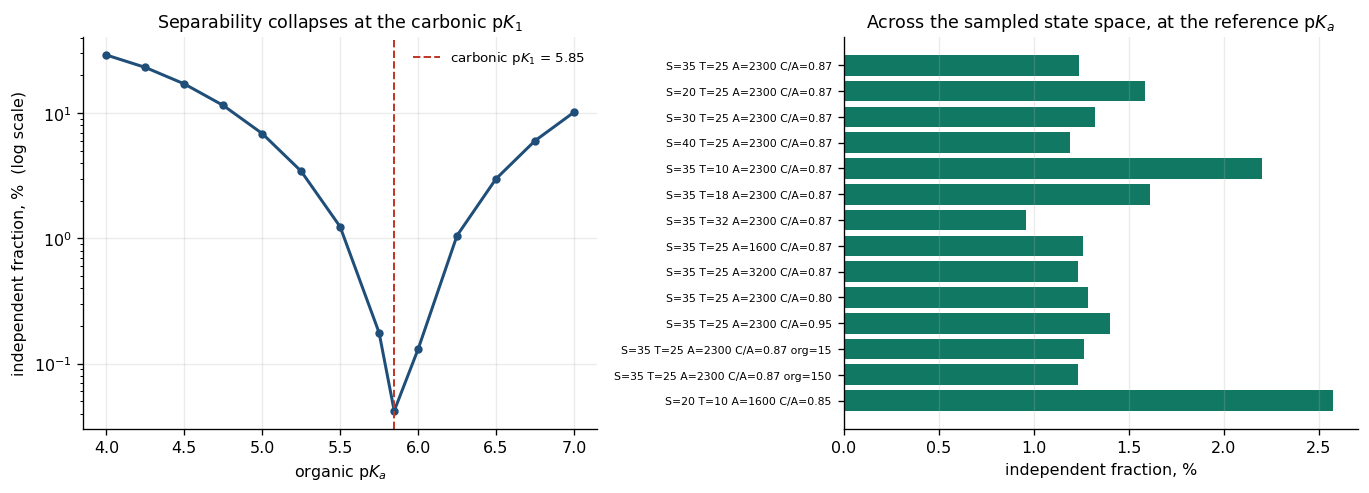

minimum separability 0.04% at organic pKa 5.85, against a carbonic pK1 of 5.85
across the 14 sampled states: 0.96% to 2.58%


In [17]:
if identifiability:
    # The pKa sweep is not stored in the JSON, so recompute it here: the
    # calculation is a Jacobian and a projection, and takes about a second.
    sys.path.insert(0, str(ROOT / "scripts"))
    from organic_identifiability import analyse

    pk1 = float(np.median([r["carbonic_pk1_total"] for r in identifiability]))
    # Include pK1 itself: on a round grid the minimum lands beside it, not on it.
    pks = np.unique(np.append(np.arange(4.0, 7.01, 0.25), round(pk1, 4)))
    indep_pk = [100 * (1 - analyse(200, float(pk))["organic_explained_by_carbonate"])
                for pk in pks]

    fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

    left.plot(pks, indep_pk, marker="o", ms=4, lw=1.8, color="#1f4e79")
    left.axvline(pk1, color="#c0392b", ls="--", lw=1.2,
                 label=rf"carbonic p$K_1$ = {pk1:.2f}")
    left.set_yscale("log")
    left.set_xlabel(r"organic p$K_a$")
    left.set_ylabel("independent fraction, %  (log scale)")
    left.set_title(r"Separability collapses at the carbonic p$K_1$")
    left.legend(fontsize=8)

    indep = [100 * (1 - r["organic_explained_by_carbonate"]) for r in identifiability]
    right.barh(range(len(identifiability)), indep, color="#117864")
    right.set_yticks(range(len(identifiability)),
                     [r["state"].replace(" org=75", "") for r in identifiability],
                     fontsize=6.5)
    right.set_xlabel("independent fraction, %")
    right.set_title("Across the sampled state space, at the reference $\\mathrm{p}K_a$")
    right.grid(axis="y", visible=False)
    right.invert_yaxis()

    fig.tight_layout()
    plt.show()

    lo = int(np.argmin(indep_pk))
    print(f"minimum separability {indep_pk[lo]:.2f}% at organic pKa {pks[lo]:.2f}, "
          f"against a carbonic pK1 of {pk1:.2f}")
    print(f"across the {len(identifiability)} sampled states: "
          f"{min(indep):.2f}% to {max(indep):.2f}%")

## What the figures establish

The curve is monotone and its equivalence point is sharp, so a titration is a well posed way to measure alkalinity.

Alkalinity moves the equivalence point; salinity and temperature change the curve's shape without moving it; carbon fraction changes the sharpness of the step. An inverse has to model all four, and the classical fit does.

Organic alkalinity is the exception, and not because its effect is small. At $150\ \mu\mathrm{mol\,kg^{-1}}$ it moves the curve by up to $0.49$ pH, more than ten times the hobbyist electrode noise. The difficulty is that its *shape* is one the carbonate system can already produce: near the carbonic $\mathrm{p}K_1$ almost the whole organic signature is reproducible by an adjustment to the two totals, so a large signal still carries little independent information. That is why it is recovered only barely, and why the useful thing the learned model does is not measure organic content but allocate proton acceptance away from carbonate.